In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('train.csv')

# 1. See the first few rows
print(df.head())

# 2. Check for missing values (This is the start of Data Cleaning)
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

In [11]:
# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop the Cabin column as it has too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Verify that there are no more missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


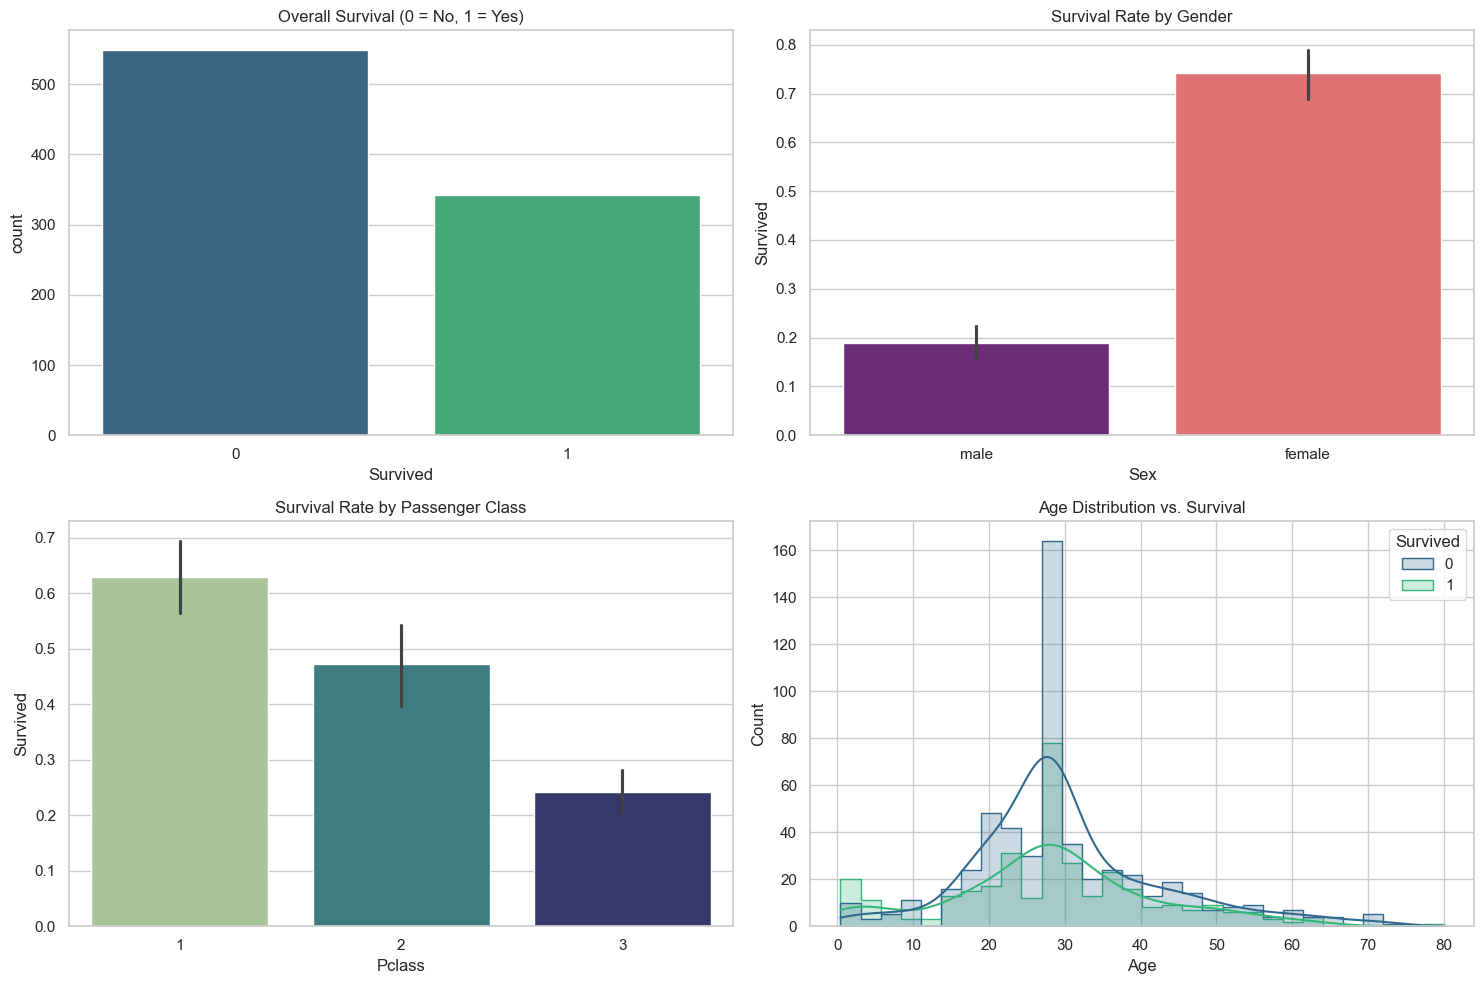

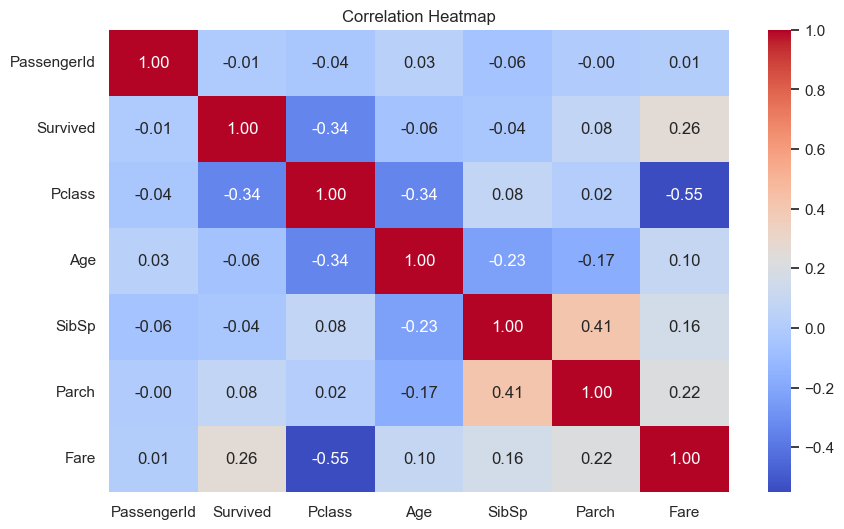

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DATA LOADING & CLEANING ---
df = pd.read_csv('train.csv')

# Handling missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# A. Survival Distribution (Fixed the palette warning)
plt.subplot(2, 2, 1)
sns.countplot(x='Survived', data=df, hue='Survived', palette='viridis', legend=False)
plt.title('Overall Survival (0 = No, 1 = Yes)')

# B. Survival Rate by Gender
plt.subplot(2, 2, 2)
sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', palette='magma', legend=False)
plt.title('Survival Rate by Gender')

# C. Survival Rate by Passenger Class
plt.subplot(2, 2, 3)
sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass', palette='crest', legend=False)
plt.title('Survival Rate by Passenger Class')

# D. Age Distribution vs. Survival
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element="step", palette='viridis')
plt.title('Age Distribution vs. Survival')

plt.tight_layout()
plt.show()

# --- 3. CORRELATION HEATMAP ---
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()